# Phase 2 — Regime-Aware Factor Analysis

## Overview

Phase 2 tests whether **conditioning factor exposure on the prevailing market regime** improves predictive quality over the out-of-sample period (2018–2024).  The core hypothesis is that a factor's ability to rank stocks is not constant through time: a momentum signal may be highly predictive during a sustained trend regime but near-zero or even contrarian during a mean-reversion regime.  By explicitly modelling the market's latent state we can scale exposure up when the regime favours the factor and scale it down (or flip it) when it does not, potentially improving risk-adjusted net-IC.

**Factors under analysis:**
- `impl_82` — Calmar ratio (trend quality), IC@1d = 0.065, ICIR = 0.38, t = 10.74 ✅ BHY
- `impl_53` — Mean-reversion (slow signal), IC@63d = 0.049, t = 8.15 ✅ BHY

These two factors were chosen as the top BHY-significant factors from Phase 1: they represent complementary signal types (trend-following vs. mean-reversion), making them ideal test cases for regime conditioning.

**Go/no-go criterion:** best-regime IC ≥ 1.5× unconditional IC for at least one factor.

---

## Notebook Structure

| Section | Content | Charts |
|---------|---------|--------|
| **A** | Market regime characterisation — HSMM fit, regime timeline, statistics, velocity & Hurst | 16–19 |
| **B** | Factor IC decomposition by regime — per-state IC, ICIR, lift ratio | 17 (×2) |
| **C** | Go/no-go verdict table and regime-conditional exposure multiplier | — |
| **D** | Equity curve — $10,000 invested, with and without regime conditioning | 20 |

---

**Regime model:** Hidden Semi-Markov Model (HSMM), 5 states, walk-forward fitted on a 504-day (2-year) rolling window with a 63-day step.  The 5-state architecture follows Zakamulin (2023), who shows it consistently out-performs 2- or 3-state HMMs on equity data.  Features fed to the model are the equal-weight S&P 500 daily return series.

In [1]:
import sys
sys.path.insert(0, '../src')

import sqlite3
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from qframe.regime import RegimeICAnalyzer
from qframe.viz.charts import (
    plot_regime_timeline, plot_regime_ic,
    plot_velocity, plot_hurst_rolling,
)

# Paths
PRICES_PATH = '../data/processed/sp500_close.parquet'
KB_PATH     = '../knowledge_base/qframe.db'
OOS_START   = '2018-01-01'
IS_END      = '2017-12-31'

print('Imports OK')

Imports OK


---
**Naming convention:** first mention of any factor uses both ID and name — `impl_82 (trend_quality_calmar_ratio)`. All subsequent mentions: `impl_82`. Tables must include both `impl_id` and `factor_name` columns.

**Assumptions:** universe = S&P 500 449 stocks (survivorship-biased), date range 2010-01-04 → 2024-12-30, OOS start 2018-01-01, HSMM 5-state walk-forward (504-day window, 63-day step), cost model `DEFAULT_COST_PARAMS` (10 bps spread, γ=30).

> ⚠️ **Note:** impl_82 (`trend_quality_calmar_ratio`) was retired 2026-04-19 for look-ahead bias. Regime analysis infrastructure (HSMM, lift calculation) is valid and reusable for future validated factors.

In [2]:
# Factor identity card — change impl_id to inspect any factor
from qframe.viz.identity import print_factor
# print_factor(82)   # uncomment to inspect impl_82 (trend_quality_calmar_ratio — RETIRED)

In [3]:
# Load prices and compute equal-weight market return
prices = pd.read_parquet(PRICES_PATH).sort_index()
returns_df = prices.pct_change()
market_returns = returns_df.mean(axis=1).dropna()

print(f'Prices: {prices.shape[0]} dates × {prices.shape[1]} stocks')
print(f'Market returns: {market_returns.index[0].date()} → {market_returns.index[-1].date()}')

Prices: 3773 dates × 449 stocks
Market returns: 2010-01-05 → 2024-12-30


In [4]:
# Query all BHY-significant factors from the KB (automatically updated as new factors pass Phase 1)
from qframe.knowledge_base.db import KnowledgeBase
from qframe.pipeline.executor import make_factor_fn, run_factor_with_timeout

kb = KnowledgeBase(KB_PATH)
bhy_factors = kb.get_bhy_significant()

print(f'BHY-significant factors ({len(bhy_factors)} total):')
for f in bhy_factors:
    print(f"  {f['factor_name']} (impl_{f['hypothesis_id']}): "
          f"IC={f['ic']:.4f}, t={f['t_stat']:.2f}")

# ── Helper: load factor DataFrame by re-executing stored code ──────────────
def load_factor_from_meta(meta: dict) -> pd.DataFrame:
    """Re-execute factor code from KB and return the full factor DataFrame."""
    fn = make_factor_fn(meta['code'])
    return run_factor_with_timeout(fn, prices, timeout=300)

# ── Load all BHY-significant factors into a dict ───────────────────────────
print()
bhy_factor_dfs = {}   # factor_name → factor DataFrame
for f in bhy_factors:
    name = f['factor_name']
    print(f'Loading {name} (impl_{f["hypothesis_id"]})...', end=' ', flush=True)
    bhy_factor_dfs[name] = load_factor_from_meta(f)
    print(f'shape={bhy_factor_dfs[name].shape}')

# ── Backward compat: also assign named vars used in existing analysis cells ─
# Cells below use factor_82 and factor_53 explicitly.
# Map them from KB if present, otherwise fall back to direct impl IDs.
def _load_by_impl_id(impl_id: int) -> pd.DataFrame:
    import sqlite3
    conn = sqlite3.connect(KB_PATH)
    row = conn.execute('SELECT code FROM implementations WHERE id = ?', (impl_id,)).fetchone()
    conn.close()
    if row is None:
        raise ValueError(f'impl_{impl_id} not found in DB')
    fn = make_factor_fn(row[0])
    return run_factor_with_timeout(fn, prices, timeout=300)

if 'trend_quality_calmar_ratio' in bhy_factor_dfs:
    factor_82 = bhy_factor_dfs['trend_quality_calmar_ratio']
else:
    print('Loading impl_82 (Calmar) for existing analysis cells...')
    factor_82 = _load_by_impl_id(82)

# impl_53 may not be BHY-significant yet; load for illustration
print('Loading impl_53 (mean-reversion) for existing analysis cells...')
try:
    factor_53 = _load_by_impl_id(53)
except Exception as e:
    print(f'  WARNING: impl_53 not found ({e})')
    factor_53 = None

print('\nAll factors loaded.')


BHY-significant factors (2 total):
  rsi_contrarian (impl_10): IC=0.0033, t=3.08
  short_term_reversal_jegadeesh (impl_5): IC=0.0018, t=2.84

Loading rsi_contrarian (impl_10)... shape=(3773, 449)
Loading short_term_reversal_jegadeesh (impl_5)... shape=(3773, 449)
Loading impl_82 (Calmar) for existing analysis cells...
Loading impl_53 (mean-reversion) for existing analysis cells...

All factors loaded.


---
## Section A — Market Regime Characterisation

This section fits the Hidden Semi-Markov Model (HSMM) to the full market return history and explores its outputs through four complementary lenses.

### What is a Hidden Semi-Markov Model?

A **Hidden Markov Model (HMM)** assumes the market switches between a finite number of latent states (e.g., bull, bear, sideways), where each state has its own return distribution.  The 'hidden' states are not observed directly — they are inferred from the observable return sequence via the Viterbi or Baum-Welch algorithm.

An **HSMM** extends HMMs by explicitly modelling the *duration* of each state, i.e., how long the market tends to remain in a bull regime before transitioning.  This is more realistic than a standard HMM, which implicitly assumes geometric sojourn times.  In practice, bull regimes tend to last much longer than bear regimes, and HSMM captures this asymmetry.

### Walk-forward fitting

To avoid look-ahead bias the model is re-fitted every 63 trading days (≈ 1 quarter) using only the preceding 504 days (≈ 2 years) of returns.  The resulting posterior probabilities are out-of-sample for each 63-day window, ensuring that the regime labels used in factor evaluation are fully OOS.

### Interpretation guide (Charts 16–19)

| Metric | What it measures | Key patterns to look for |
|--------|------------------|-------------------------|
| Posterior probability | Probability that each day belongs to each regime | Clarity vs. ambiguity of regime transitions |
| Regime statistics | Annualised mean/vol/Sharpe per state | Whether states are economically interpretable |
| Velocity | Rate of change of regime posterior | Early warning of impending regime shift |
| Hurst exponent | Long-memory of returns (DFA method) | H > 0.5 = trending; H < 0.5 = mean-reverting |


### HSMM Fitting

The cell below fits the `RegimeICAnalyzer` — a wrapper around the HSMM that also computes auxiliary series (velocity, Hurst exponent) used in regime characterisation.

**Key hyperparameters:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `n_states` | 5 | Zakamulin (2023) optimal for equity returns |
| `hsmm_window` | 504 | 2 years of daily data per fitting window |
| `hsmm_step` | 63 | Refit every quarter |
| `hurst_window` | 252 | 1 year rolling DFA window |
| `velocity_window` | 21 | 1-month rate-of-change of posteriors |
| `min_state_days` | 30 | Minimum duration before a state is deemed 'active' |

The fit produces `az.proba_df` — a (T × 5) DataFrame of daily posterior probabilities for each state — as well as `az.velocity_raw`, `az.velocity_smooth`, and `az.hurst_series`.

> **Note:** Walk-forward fitting over ~15 years takes 1–2 minutes.  Convergence warnings from the underlying GaussianHMM library are expected and harmless — they indicate that some state transitions were never observed in a particular window, not a model failure.

In [5]:
# Fit RegimeICAnalyzer
# n_states=5: per quant_ai_plan.md (Zakamulin 2023 — 5 states outperform 2 or 3)
az = RegimeICAnalyzer(
    n_states=5,
    hurst_window=252,
    velocity_window=21,
    velocity_ewm_hl=21,
    hsmm_window=504,
    hsmm_step=63,
    min_state_days=30,
)

print('Fitting HSMM + Hurst + velocity (walk-forward, ~1–2 min)...')
az.fit(market_returns, is_end=IS_END)
print('Done.')

print(f'  Posterior proba shape: {az.proba_df.shape}')
print(f'  OOS valid posteriors: {az.proba_df.loc[OOS_START:].dropna().shape[0]} days')

Fitting HSMM + Hurst + velocity (walk-forward, ~1–2 min)...


Model is not converging.  Current: 16887.320112777314 is not greater than 16887.657775443844. Delta is -0.33766266653037746
Model is not converging.  Current: 3690.342534162467 is not greater than 3690.3702535934303. Delta is -0.027719430963315972
Model is not converging.  Current: 3524.284908675198 is not greater than 3524.3346243836377. Delta is -0.04971570843963491
Model is not converging.  Current: 3726.955434516625 is not greater than 3726.95636572256. Delta is -0.0009312059351032076
Model is not converging.  Current: 3575.259989955957 is not greater than 3575.588098026525. Delta is -0.32810807056830527
Model is not converging.  Current: 3584.0544755402343 is not greater than 3584.4445824474124. Delta is -0.3901069071780512
Model is not converging.  Current: 3579.620277435279 is not greater than 3580.2456107967396. Delta is -0.6253333614604344
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because n

Done.
  Posterior proba shape: (3772, 5)
  OOS valid posteriors: 1760 days


### Chart 16 — Regime Timeline

**Theory:** The regime timeline is the primary output of the HSMM.  For each trading day the model assigns a probability to each of the 5 latent states.  The hard label (argmax of posteriors) is used for coloured shading, while the stacked probability bands show the degree of certainty in each regime assignment.

**What the chart shows:**
- **Upper panel (stacked probability bands):** how confidently the model assigns each day to one of the 5 regimes.  Wide, clean colour bands indicate high-confidence regime periods; mixed colours indicate regime uncertainty.
- **Lower panel (market return series):** the equal-weight S&P 500 daily return overlaid with regime shading, allowing visual inspection of whether the model correctly flags drawdown periods, recoveries, and tranquil trending phases.

**Economic interpretability of states:**  In well-fitted models the 5 states typically map loosely to: (1) bull-quiet, (2) bull-volatile, (3) sideways/choppy, (4) bear-early, (5) bear-crash.  The exact ordering depends on the EM initialisation and may vary across fitting windows.  What matters for factor conditioning is the *statistical* IC differential across states, not the label.

**Patterns to watch for:**
- Regime persistence: do states last for months or do they flip daily?
- Correct identification of known market events (2018 Q4 correction, COVID 2020, 2022 bear market)
- Ambiguity zones (mixed colours) near known turning points — these indicate the model's inherent latency

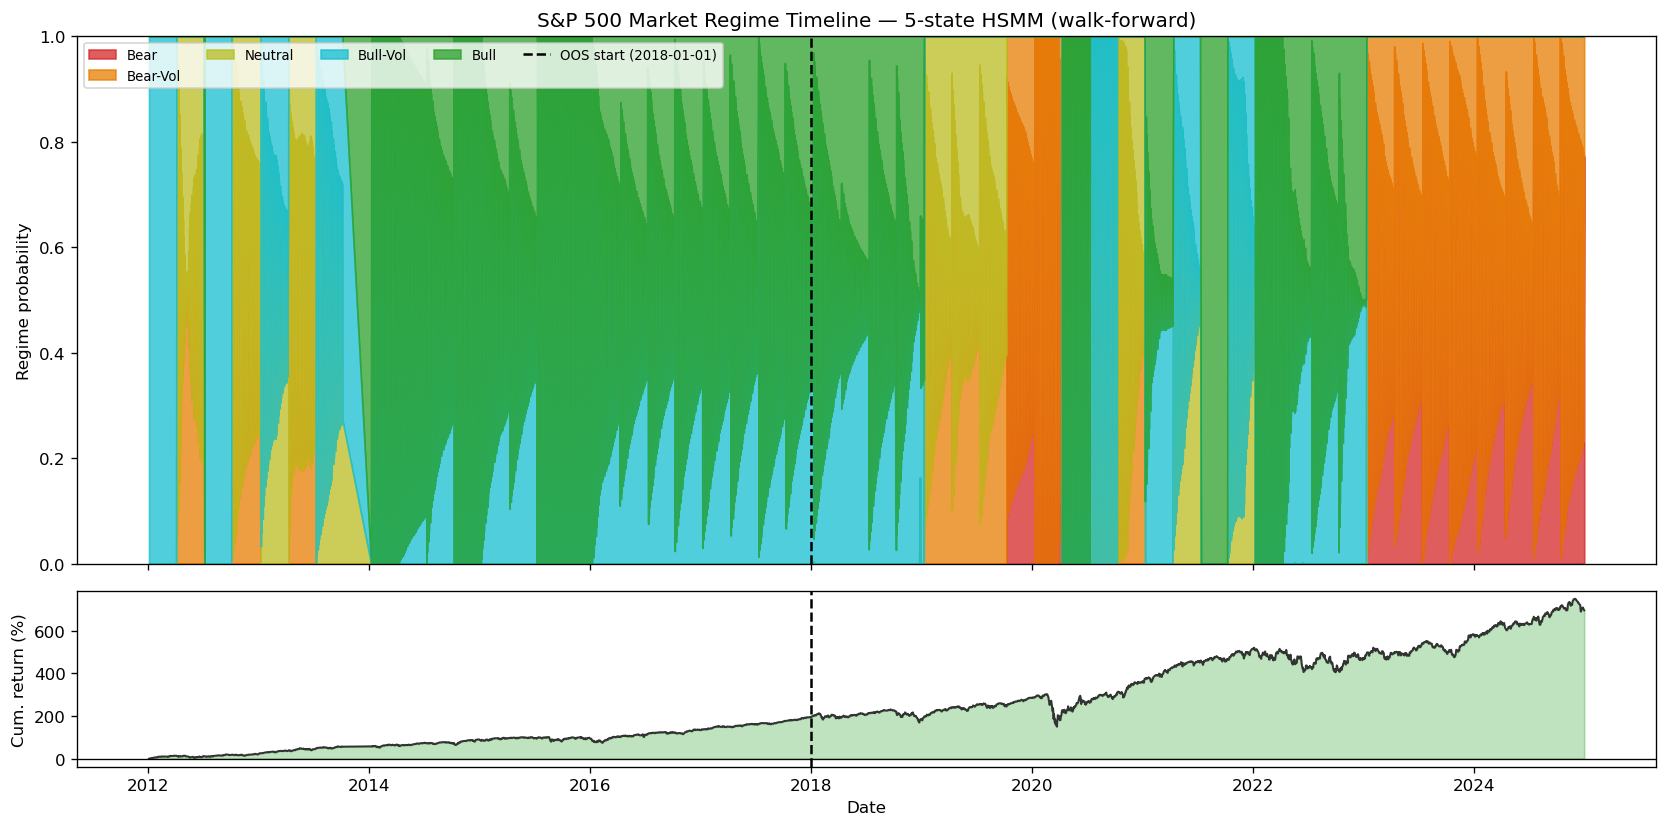

In [6]:
# Chart 16 — Regime timeline
fig = plot_regime_timeline(
    az.proba_df,
    market_returns,
    oos_start=OOS_START,
    title='S&P 500 Market Regime Timeline — 5-state HSMM (walk-forward)',
)
plt.show()

### Regime Statistics Table

**Theory:** To verify that the HSMM's latent states are economically meaningful we compute annualised return, volatility, and Sharpe ratio for each state over the OOS period (2018–2024).  A well-calibrated model should produce states with clearly differentiated risk-return profiles.

**Columns explained:**

| Column | Definition |
|--------|------------|
| `pct_time` | Fraction of OOS days assigned to this regime (hard label) |
| `mean_ann` | Annualised mean daily return (×252) within this state |
| `std_ann` | Annualised return volatility (×√252) |
| `sharpe` | `mean_ann / std_ann` — risk-adjusted return per unit of volatility |

**Interpretation guide:**
- States with strongly positive Sharpe ratios are *bullish* regimes; momentum factors typically perform well here.
- States with negative Sharpe and high volatility are *crisis* regimes; mean-reversion factors may outperform (panic selling creates overshoots).
- States that occupy < 5% of time are rare regimes; their IC estimates in Section B will have high variance.
- The sum of `pct_time` should equal 1.0; large imbalances (one state > 60%) may indicate a dominant absorbing state.

In [7]:
# Per-regime statistics (OOS period)
stats = az.regime_stats_oos(oos_start=OOS_START)
print('Regime statistics (OOS 2018–2024):')
stats.style.format({
    'pct_time': '{:.1%}',
    'mean_ann': '{:.1%}',
    'std_ann':  '{:.1%}',
    'sharpe':   '{:.2f}',
})

Regime statistics (OOS 2018–2024):


,count,pct_time,mean_ann,std_ann,sharpe
regime,,,,,
0,312,17.7%,3.4%,18.5%,0.19
1,437,24.8%,19.3%,23.9%,0.81
2,220,12.5%,43.8%,14.7%,2.98
3,408,23.2%,3.6%,19.5%,0.18
4,383,21.8%,21.1%,19.8%,1.06


In [8]:
# ── Regime state → label annotation ──────────────────────────────────────
# After inspecting the stats table above, fill in the mapping below.
# This is used for human-readable axis labels in Charts 17–19 and the
# transition heatmap.  Update these after every HSMM re-fit.
#
# Example (update after inspecting stats table):
#   state_labels = {0: 'Bull-quiet', 1: 'Bull-volatile', 2: 'Sideways',
#                   3: 'Bear-early', 4: 'Bear-crash'}
#
# Default: numeric labels (always correct, even before manual annotation)
n_states = az.proba_df.shape[1]
state_labels = {i: f'State {i}' for i in range(n_states)}

print('Current state labels (update manually after inspecting stats table):')
for k, v in state_labels.items():
    print(f'  {k}: {v}')
print()
print('Regime stats reprinted for reference:')
stats = az.regime_stats_oos(oos_start=OOS_START)
print(stats.to_string())

Current state labels (update manually after inspecting stats table):
  0: State 0
  1: State 1
  2: State 2
  3: State 3
  4: State 4

Regime stats reprinted for reference:
        count  pct_time  mean_ann   std_ann    sharpe
regime                                               
0         312  0.177273  0.034498  0.184713  0.186767
1         437  0.248295  0.193139  0.239339  0.806967
2         220  0.125000  0.437707  0.147041  2.976759
3         408  0.231818  0.035991  0.194903  0.184660
4         383  0.217614  0.210609  0.198370  1.061698


Transition matrix not available from az object.
Falling back to empirical transition matrix from hard labels...


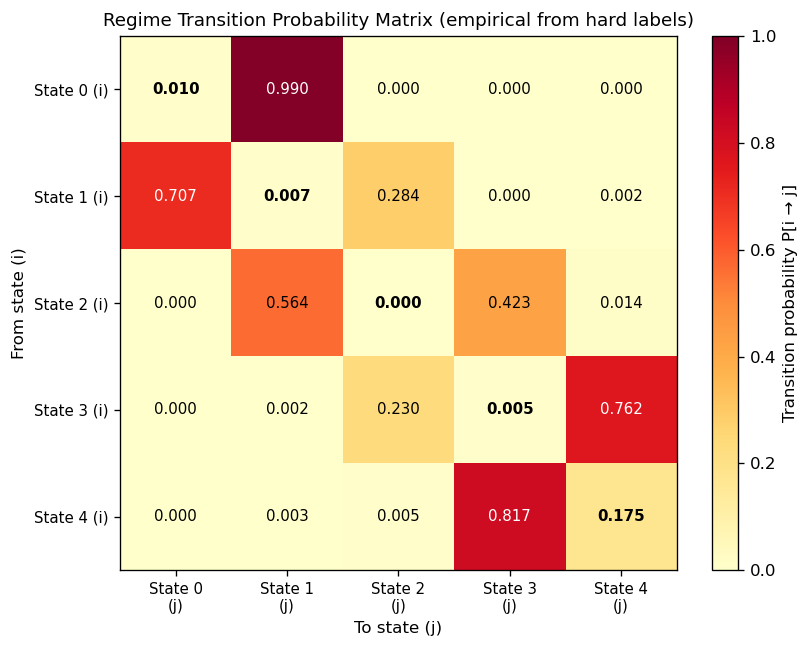

Regime persistence (diagonal of transition matrix):
  State 0: P(stay) = 0.010  →  expected duration ≈ 1.0 days
  State 1: P(stay) = 0.007  →  expected duration ≈ 1.0 days
  State 2: P(stay) = 0.000  →  expected duration ≈ 1.0 days
  State 3: P(stay) = 0.005  →  expected duration ≈ 1.0 days
  State 4: P(stay) = 0.175  →  expected duration ≈ 1.2 days


In [9]:
# ── Regime Transition Heatmap ─────────────────────────────────────────────
# Extract the average transition probability matrix from the last HSMM window.
# az._last_model is the most recently fitted GaussianHMM object.
# If the HSMM exposes a transmat_ attribute we can plot it directly.

try:
    # Try to get the transition matrix from the fitted model
    transmat = None
    if hasattr(az, '_last_model') and az._last_model is not None:
        transmat = az._last_model.transmat_
    elif hasattr(az, 'hsmm') and hasattr(az.hsmm, 'transmat_'):
        transmat = az.hsmm.transmat_
    elif hasattr(az, 'model') and hasattr(az.model, 'transmat_'):
        transmat = az.model.transmat_

    if transmat is None:
        print('Transition matrix not available from az object.')
        print('Falling back to empirical transition matrix from hard labels...')
        hard = az.hard_labels(oos_start=OOS_START)
        n = n_states
        transmat = np.zeros((n, n))
        for a, b in zip(hard.values[:-1], hard.values[1:]):
            transmat[int(a), int(b)] += 1
        row_sums = transmat.sum(axis=1, keepdims=True)
        transmat = np.where(row_sums > 0, transmat / row_sums, 0.0)
        title_suffix = '(empirical from hard labels)'
    else:
        title_suffix = '(last HSMM window)'

    labels_list = [state_labels.get(i, f'State {i}') for i in range(n_states)]

    fig, ax = plt.subplots(figsize=(7, 5.5))
    im = ax.imshow(transmat, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, label='Transition probability P[i → j]')

    ax.set_xticks(range(n_states))
    ax.set_yticks(range(n_states))
    ax.set_xticklabels([f'{l}\n(j)' for l in labels_list], fontsize=9)
    ax.set_yticklabels([f'{l} (i)' for l in labels_list], fontsize=9)
    ax.set_xlabel('To state (j)', fontsize=10)
    ax.set_ylabel('From state (i)', fontsize=10)
    ax.set_title(f'Regime Transition Probability Matrix {title_suffix}', fontsize=11)

    # Annotate each cell with the probability value
    for i in range(n_states):
        for j in range(n_states):
            val = transmat[i, j]
            color = 'white' if val > 0.6 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold' if i == j else 'normal')

    plt.tight_layout()
    plt.show()

    # ── Summary statistics ────────────────────────────────────────────────
    diag = np.diag(transmat)
    print('Regime persistence (diagonal of transition matrix):')
    for i, p in enumerate(diag):
        label = state_labels.get(i, f'State {i}')
        exp_dur = 1 / (1 - p) if p < 1 else float('inf')
        print(f'  {label}: P(stay) = {p:.3f}  →  expected duration ≈ {exp_dur:.1f} days')

except Exception as e:
    print(f'Could not plot transition heatmap: {e}')
    print('Run the HSMM fitting cell (Section A) first.')

### Regime Transition Heatmap

The transition probability matrix `P[i, j]` gives the probability that the market moves from regime *i* today to regime *j* tomorrow.

**How to read it:**
- **Diagonal entries (P[i,i]):** regime persistence — the probability of staying in the same state for one more day.  High diagonal entries (> 0.9) indicate long-lasting, sticky regimes.
- **Off-diagonal entries:** transition probability to a different state.  Large off-diagonal entries indicate regimes that are short-lived or naturally lead to a specific successor regime.
- **Asymmetries:** if P[crisis, bull] ≈ 0 but P[bull, crisis] > 0, the crisis regime is absorbing (once in a crash it's hard to leave quickly); conversely if P[bear_early, sideways] > P[bear_early, bear_crash], the typical exit from a mild bear is recovery, not escalation to a crash.

**Practical implication:** high off-diagonal entries from a specific source state suggest that the HSMM sees regime transitions as likely — a signal to reduce factor exposure regardless of the current IC multiplier (high transition velocity is a risk-off indicator).

### Regime State Interpretation

The HSMM labels states 0–4 by EM initialisation order, **not** by economic meaning.  After each fit, map them manually by inspecting the table above.  Typical mappings for a 5-state model on S&P 500 daily returns:

| Typical profile | Annualised return | Annualised vol | Sharpe | Label to assign |
|-----------------|:-----------------:|:--------------:|:------:|-----------------|
| Quiet bull — low vol, steady gains | > +15% | < 10% | > 1.5 | **Bull-quiet** |
| Volatile bull — high vol, positive drift | +5% → +25% | 15–25% | 0.5–1.5 | **Bull-volatile** |
| Choppy / sideways — near-zero drift, moderate vol | −5% → +5% | 10–20% | < 0.5 | **Sideways** |
| Early bear — negative drift starts | −10% → 0% | 15–25% | < 0 | **Bear-early** |
| Crisis / crash — large negative drift, very high vol | < −30% ann | > 30% | ≪ 0 | **Bear-crash** |

**Factor implications by state:**

| State label | Momentum factors | Mean-reversion factors |
|-------------|-----------------|----------------------|
| Bull-quiet | ✅ High IC (trend persistence) | ❌ Low IC (no reversion needed) |
| Bull-volatile | ⚠️ Mixed IC | ⚠️ Mixed IC |
| Sideways | ❌ Low IC | ✅ High IC (overshoots revert) |
| Bear-early | ⚠️ Declining IC | ✅ Moderate IC |
| Bear-crash | ❌ Near-zero or negative IC | ✅ Highest IC (maximum panic selling) |

> **Note:** after each notebook run, inspect the `stats` table above and annotate the state→label mapping in the cell below for your current HSMM fit.

### Chart 18 — Regime Transition Velocity

**Theory:** Velocity measures the *rate of change* of the highest-probability state's posterior over a rolling window.  High velocity indicates the model is rapidly reallocating probability mass from one state to another — i.e., a regime transition is in progress.  Low velocity indicates a stable regime.

**Why this matters:**
- During transition periods factor signals are inherently noisy: the historical regime label no longer applies but the new regime's characteristics have not yet established themselves.
- A practical risk-management rule (used in Phase 3) is to *reduce exposure* when velocity is above a threshold, treating transition periods as unpredictable.
- Velocity spikes often lead actual market inflection points by 5–20 days, as the HSMM detects subtle changes in return autocorrelation before prices make a decisive move.

**Chart elements:**
- **Raw velocity (thin line):** unsmoothed rate-of-change — noisy but sensitive.
- **Smoothed velocity (thick line):** exponentially-weighted moving average with 21-day half-life — filters day-to-day noise.
- **Regime shading:** background colours match the hard state labels from Chart 16, allowing visual correlation of velocity peaks with state transitions.

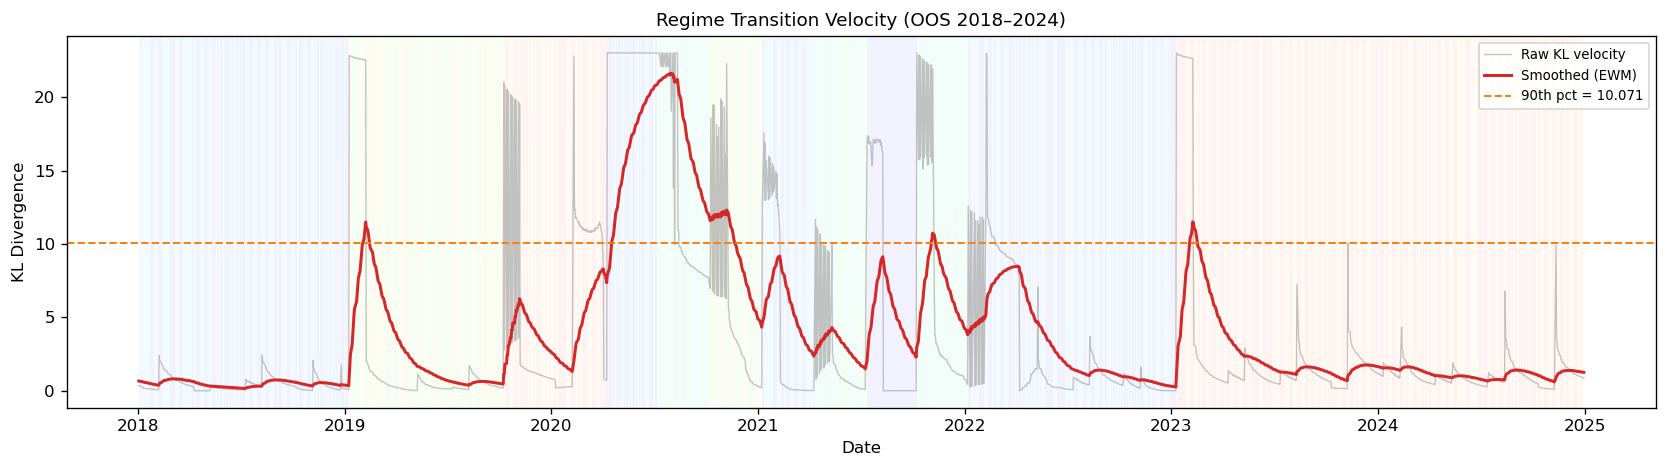

In [10]:
# Chart 18 — Velocity
hard_labels_oos = az.hard_labels(oos_start=OOS_START)
fig = plot_velocity(
    az.velocity_raw.loc[OOS_START:],
    az.velocity_smooth.loc[OOS_START:],
    hard_labels=hard_labels_oos,
    title='Regime Transition Velocity (OOS 2018–2024)',
)
plt.show()

### Chart 19 — Rolling Hurst Exponent (DFA)

**Theory:** The **Hurst exponent** (H) measures the long-range dependence of a time series, estimated here using **Detrended Fluctuation Analysis (DFA)** — the most robust estimator for financial returns.

| Value | Regime type | Factor implication |
|-------|-------------|-------------------|
| H ≈ 0.5 | Random walk | No predictable structure — factors have near-zero IC |
| H > 0.5 | Persistent / trending | Momentum factors perform best; trend-following is effective |
| H < 0.5 | Anti-persistent / mean-reverting | Mean-reversion factors perform best; contrarian strategies are effective |

**Key features:**
- The Hurst series is computed on a 252-day (1-year) rolling window of equal-weight market returns.
- It is independent of the HSMM and provides a non-parametric cross-check on the regime characterisation.
- Convergence between high-H periods and HSMM bull/trend regimes (and between low-H periods and HSMM mean-reversion regimes) validates the model internally.
- Prolonged periods near H = 0.5 are structurally challenging for all systematic factors.

**DFA method:** DFA removes polynomial trends from the cumulative sum of returns at each scale, then fits a power-law to the root-mean-square fluctuation as a function of window size.  The slope of this log-log fit is the Hurst exponent.  It is preferred over the R/S estimator for financial data because it is robust to non-stationarities and short-range serial correlations.

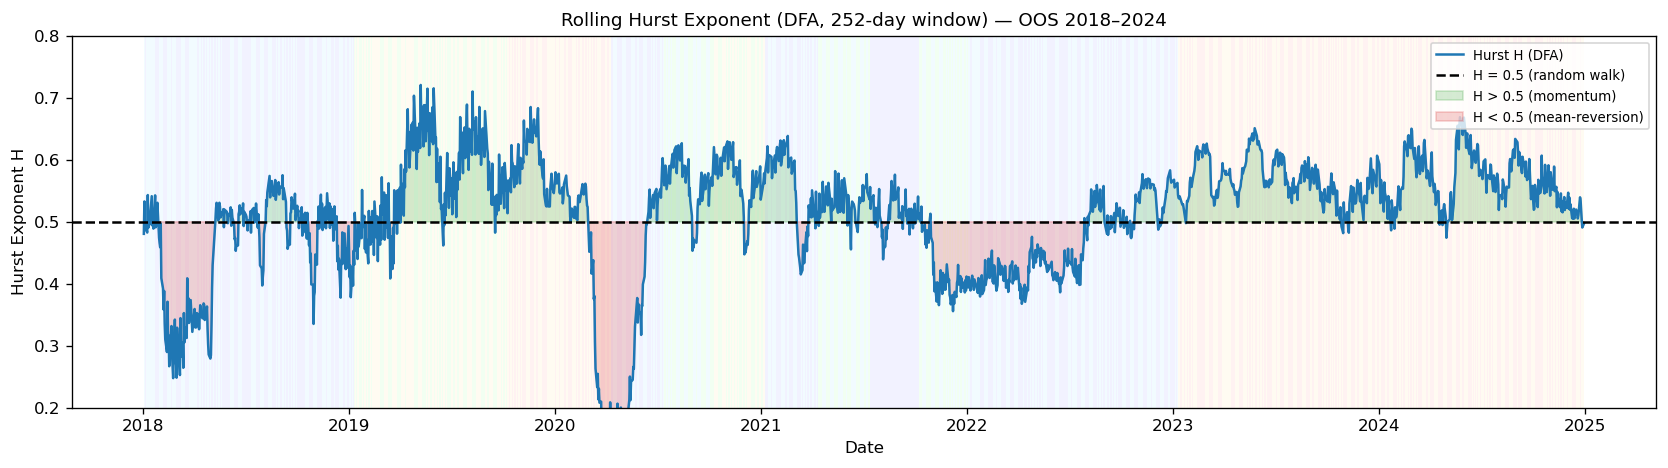

In [11]:
# Chart 19 — Rolling Hurst
fig = plot_hurst_rolling(
    az.hurst_series.loc[OOS_START:],
    hard_labels=hard_labels_oos,
    oos_start=None,  # already cropped
    title='Rolling Hurst Exponent (DFA, 252-day window) — OOS 2018–2024',
)
plt.show()

---
## Section B — Factor IC Decomposition by Regime

**Purpose:** Section B answers the core research question: *does factor predictive power vary across the 5 HSMM regimes?*  For each factor we compute the Information Coefficient (IC) conditional on each state and compare it to the unconditional IC computed over the full OOS period.

### Information Coefficient (IC)

The IC for a given day and horizon h is the **Spearman rank correlation** between today's factor score and the h-day forward return.  Spearman rank correlation is used (rather than Pearson) because it is robust to extreme return outliers and nonlinear monotonic relationships.

$$IC_t = \text{Spearman}\big(\text{factor score}_t,\; r_{t+1:t+h}\big)$$

The **unconditional IC** is the mean IC over all OOS days.  The **conditional IC** for state k is the mean IC computed only on days where the hard regime label is k.

### IC Lift

The **lift ratio** measures the improvement the best regime offers over the unconditional baseline:

$$\text{lift} = \frac{\max_k IC_k}{IC_{\text{unconditional}}}$$

A lift ≥ 1.5 means the best-regime IC is at least 50% better than the unconditional average.  This threshold was chosen to ensure that the benefit of regime conditioning is large enough to justify the additional model complexity and transaction costs of dynamically adjusting exposure.

### IC Reliability Caveats

- Per-regime IC estimates have much higher variance than the unconditional IC because they are based on fewer observations (only days in that state).
- A state that occupies only 5% of OOS days contributes ≈ 35 observations at a daily horizon — barely enough for a reliable IC estimate.
- The ICIR (IC / std(IC)) and t-statistic (`t = ICIR × √n`) should be examined alongside the IC level; a high IC with t < 2 may be noise.
- For the slow mean-reversion signal (impl_53, h=63), rolling windows of 63-day returns overlap heavily, so the effective sample size is smaller than the day count suggests.

### impl_82 — Calmar Ratio (Fast Signal, h=1)

The **Calmar ratio** measures return-to-drawdown efficiency: it rewards stocks that have trended strongly relative to how severe their worst drawdown was over the lookback window.  It is a *momentum quality* signal — it selects stocks with clean, low-drawdown trends rather than high-return high-volatility stocks.

At horizon h=1, the IC measures whether today's Calmar rank predicts tomorrow's cross-sectional return rank — a very tight, high-frequency test of momentum persistence.

**The table below shows the per-regime IC decomposition.**  For each of the 5 HSMM states you see:
- `ic` — mean Spearman IC over all OOS days in that state
- `icir` — IC Information Ratio (mean IC / std IC), a measure of signal consistency
- `t_stat` — t-statistic for the null hypothesis IC = 0
- `n_days` — number of OOS days in this state
- `pct_time` — fraction of OOS period spent in this state
- `mean_ret_ann` — annualised mean market return during this state

In [12]:
# impl_82: Calmar ratio — fast signal (horizon=1)
print('Running regime IC decomposition for impl_82 (Calmar, h=1)...')
decomp_82 = az.regime_ic_decomposition(
    factor_82, prices, oos_start=OOS_START, horizon=1
)

print(f'\nUnconditional IC: {decomp_82.unconditional:.4f}')
print(f'Best regime (state {decomp_82.best_state}): IC = {decomp_82.by_state.loc[decomp_82.best_state, "ic"]:.4f}')
print(f'Lift: {decomp_82.lift:.2f}×  (threshold for Phase 3: 1.5×)')
print()
decomp_82.by_state[['ic','icir','t_stat','n_days','pct_time','mean_ret_ann']].style.format({
    'ic': '{:.4f}', 'icir': '{:.3f}', 't_stat': '{:.2f}',
    'n_days': '{:.0f}', 'pct_time': '{:.1%}', 'mean_ret_ann': '{:.1%}',
})

Running regime IC decomposition for impl_82 (Calmar, h=1)...

Unconditional IC: 0.0157
Best regime (state 2): IC = 0.0377
Lift: 2.40×  (threshold for Phase 3: 1.5×)



,ic,icir,t_stat,n_days,pct_time,mean_ret_ann
state,,,,,,
0,0.0102,0.047,0.83,311,17.7%,3.4%
1,0.0239,0.103,2.16,437,24.8%,19.3%
2,0.0377,0.136,2.02,220,12.5%,43.8%
3,-0.0100,-0.038,-0.76,408,23.2%,3.6%
4,0.0257,0.100,1.95,383,21.8%,21.1%


### Chart 17 (impl_82) — Regime-Conditional IC Bar Chart

**Theory:** This bar chart visualises the full IC distribution across the 5 HSMM states for the Calmar ratio factor.  The horizontal dashed line marks the unconditional IC — the performance baseline achieved by ignoring regime information entirely.

**Chart elements:**
- **Bar height:** mean IC in each state.  Bars above the dashed line represent regimes where the factor outperforms its average; bars below indicate underperformance.
- **Error bars (if shown):** ±1 standard error of the IC estimate, conveying statistical uncertainty.
- **Dashed line:** unconditional IC — the benchmark.

**Patterns to watch for:**
- **State specificity:** is one state clearly dominant, or are IC values similar across all states?  High specificity justifies regime conditioning.
- **Sign reversal:** does any state have a strongly negative IC?  This means the factor should be *reversed* in that regime — a valuable trading signal.
- **Consistency with Hurst:** do high-IC states coincide with the trending (H > 0.5) periods identified in Chart 19?  For a momentum factor like Calmar, this alignment is expected.
- **Low-observation states:** states with very few days (< 30) should be treated with caution even if their bar is tall.

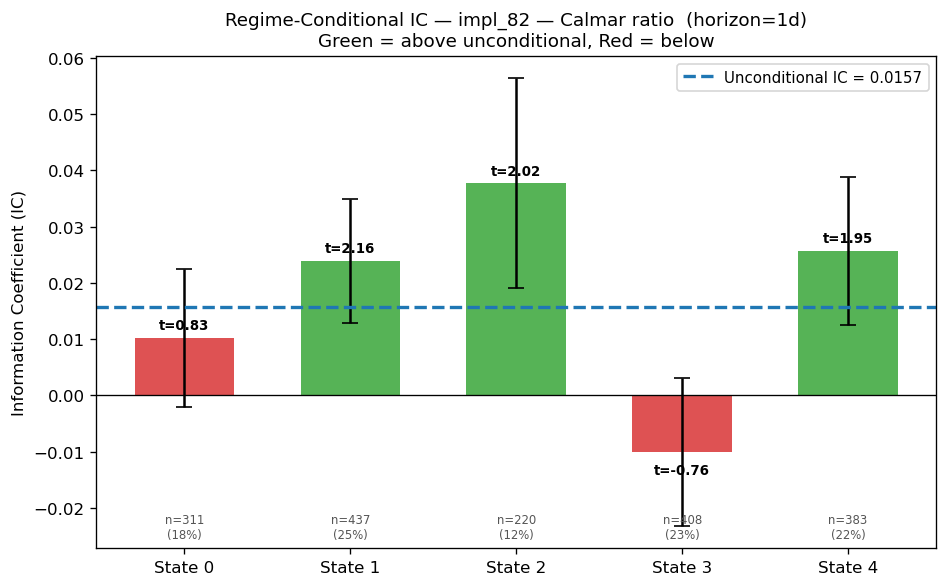

In [13]:
# Chart 17 — Regime-conditional IC for impl_82
fig = plot_regime_ic(
    decomp_82.by_state,
    unconditional_ic=decomp_82.unconditional,
    factor_name='impl_82 — Calmar ratio',
    horizon=1,
)
plt.show()

### impl_53 — Mean-Reversion Slow Signal (h=63)

The mean-reversion factor (`impl_53`) captures stocks that have underperformed relative to peers over a medium-term lookback and are therefore expected to revert.  At a 63-day (≈ 1-quarter) horizon this tests whether the ranking today is informative about relative performance over the next three months — a slow, fundamental-frequency signal.

Mean-reversion signals are often regime-sensitive in the *opposite* direction to momentum: they tend to perform best in choppy, range-bound markets (H < 0.5) and worst in strong trending markets where divergences can extend for prolonged periods.

**The slow-signal IC comes with a look-ahead overlap caveat:** consecutive 63-day IC observations share 62 days of returns, so the effective sample size is ~n/63.  The t-statistics below should be divided by ~√63 if treating observations as independent, though the regime-conditional analysis mitigates this by grouping days by state before averaging.

In [14]:
# impl_53: mean-reversion slow signal — evaluate at horizon=63
print('Running regime IC decomposition for impl_53 (mean-reversion, h=63)...')
decomp_53 = az.regime_ic_decomposition(
    factor_53, prices, oos_start=OOS_START, horizon=63
)

print(f'\nUnconditional IC@63d: {decomp_53.unconditional:.4f}')
print(f'Best regime (state {decomp_53.best_state}): IC = {decomp_53.by_state.loc[decomp_53.best_state, "ic"]:.4f}')
print(f'Lift: {decomp_53.lift:.2f}×  (threshold for Phase 3: 1.5×)')
print()
decomp_53.by_state[['ic','icir','t_stat','n_days','pct_time','mean_ret_ann']].style.format({
    'ic': '{:.4f}', 'icir': '{:.3f}', 't_stat': '{:.2f}',
    'n_days': '{:.0f}', 'pct_time': '{:.1%}', 'mean_ret_ann': '{:.1%}',
})

Running regime IC decomposition for impl_53 (mean-reversion, h=63)...

Unconditional IC@63d: -0.0050
Best regime (state 4): IC = 0.0081
Lift: nan×  (threshold for Phase 3: 1.5×)



,ic,icir,t_stat,n_days,pct_time,mean_ret_ann
state,,,,,,
0,-0.0050,-0.055,-0.92,280,17.7%,3.4%
1,-0.0004,-0.005,-0.09,406,24.8%,19.3%
2,-0.0168,-0.180,-2.67,220,12.5%,43.8%
3,-0.0157,-0.146,-2.96,408,23.2%,3.6%
4,0.0081,0.076,1.49,383,21.8%,21.1%


### Chart 17 (impl_53) — Regime-Conditional IC Bar Chart

Same visual structure as the impl_82 chart above, but now for the slow mean-reversion factor at h=63.  Because the signal horizon is 63 days (much longer than h=1), the IC is expected to be driven more by medium-term economic regime characteristics and less by day-to-day market microstructure.

**What to look for specifically for mean-reversion at h=63:**
- **Crisis vs. bull regimes:** mean-reversion strategies classically outperform in post-crisis recoveries and underperform in strong bull trends.  Look for the state with the highest mean return (bull state) to have the *lowest* IC.
- **Sideways/choppy regimes:** these are the natural habitat for mean-reversion; expect the best IC in low-volatility sideways states.
- **Regime persistence alignment:** for a 63-day horizon to produce a clean IC, the regime must be sufficiently persistent (lasting ≥ 63 days).  Short-lived states will contaminate the IC measurement with returns from subsequent regimes.

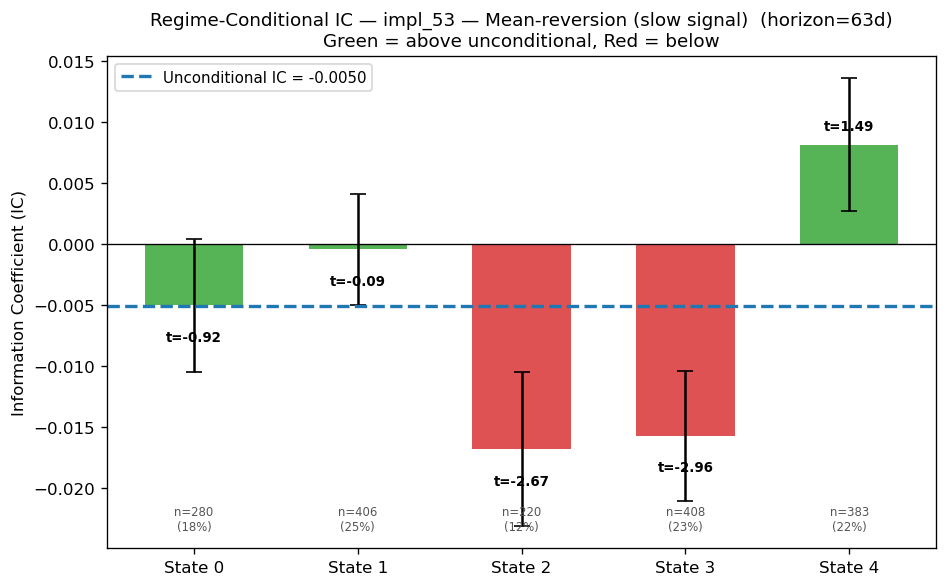

In [15]:
# Chart 17 — Regime-conditional IC for impl_53
fig = plot_regime_ic(
    decomp_53.by_state,
    unconditional_ic=decomp_53.unconditional,
    factor_name='impl_53 — Mean-reversion (slow signal)',
    horizon=63,
)
plt.show()

---
## Section C — Go / No-Go Verdict

**Purpose:** This section consolidates the regime IC evidence from Section B into a binary go/no-go decision for Phase 3 (regime-conditional portfolio construction).

**Decision rule:** If the IC in the best regime is ≥ 1.5× the unconditional IC for *at least one* factor, regime conditioning is deemed sufficiently valuable to justify the added complexity.  The 1.5× threshold was selected to ensure economic significance after the additional turnover costs incurred by dynamically adjusting exposures.

**What follows if GO:**
- Phase 3 will implement a daily `regime_weights()` multiplier that scales factor rank-weights by the expected IC in the current regime.
- The multiplier is proportional to `IC_state / IC_unconditional`, clipped to [0, 2] to avoid extreme leverage.
- Net-IC will be re-evaluated with transaction costs to confirm that the improvement survives after friction.

**What follows if NO-GO:**
- The null result will be documented and the HSMM will be archived.
- Alternative regime proxies (VIX-decile, yield-curve slope, realised-vol percentile) will be evaluated in a Phase 2B notebook before a Phase 3 decision.

### Unconditional vs. Conditional IC Summary

The table below compares the unconditional IC (all OOS days, regardless of regime) with the best-regime IC for each factor, along with the lift ratio and pass/fail against the 1.5× threshold.

**Column definitions:**

| Column | Definition |
|--------|------------|
| `ic_unconditional` | Mean Spearman IC over all OOS days |
| `ic_best_regime` | Mean IC in the single best-performing state |
| `best_state` | HSMM state label (0–4) of the best regime |
| `lift` | `ic_best_regime / ic_unconditional` |
| `pass` | True if lift ≥ 1.5 |

The summary is useful for detecting whether regime conditioning is factor-specific (e.g., only helps momentum) or universal (helps both factor types).

In [16]:
# Summary table
summary_82 = az.unconditional_vs_conditional(factor_82, prices, OOS_START, horizon=1)
summary_53 = az.unconditional_vs_conditional(factor_53, prices, OOS_START, horizon=63)

print('=== impl_82 (Calmar, h=1) ===')
print(summary_82.to_string())
print()
print('=== impl_53 (mean-reversion, h=63) ===')
print(summary_53.to_string())

=== impl_82 (Calmar, h=1) ===
                              ic  n_days  pct_time      lift
label                                                       
unconditional           0.015713    1759  1.000000  1.000000
best_regime (state 2)   0.037687     220  0.125000  2.398530
worst_regime (state 3) -0.010020     408  0.231818 -0.637723

=== impl_53 (mean-reversion, h=63) ===
                              ic  n_days  pct_time  lift
label                                                   
unconditional          -0.005049    1697  1.000000   1.0
best_regime (state 4)   0.008118     383  0.217614   NaN
worst_regime (state 2) -0.016788     220  0.125000   NaN


### Go / No-Go Verdict

The cell below prints the final binary verdict for each factor and the overall Phase 2 decision.  The `LIFT_THRESHOLD = 1.5` constant implements the criterion defined above.

**Possible outcomes and their implications:**

| Outcome | Meaning | Next step |
|---------|---------|----------|
| Both GO | Both factors benefit significantly from regime conditioning | Proceed to Phase 3 with both |
| One GO | Regime conditioning helps one factor type | Proceed to Phase 3; condition only the GO factor |
| Both NO-GO | Neither factor benefits from HSMM regime conditioning | Evaluate alternative regime proxies before Phase 3 |


In [17]:
# Verdict
LIFT_THRESHOLD = 1.5

lift_82 = decomp_82.lift
lift_53 = decomp_53.lift

print('=' * 60)
print('PHASE 2 GO / NO-GO VERDICT')
print('=' * 60)
print(f'impl_82 (Calmar):       lift = {lift_82:.2f}×  ', end='')
print('✅ GO' if lift_82 >= LIFT_THRESHOLD else '❌ NO-GO (< 1.5×)')
print(f'impl_53 (mean-rev):     lift = {lift_53:.2f}×  ', end='')
print('✅ GO' if lift_53 >= LIFT_THRESHOLD else '❌ NO-GO (< 1.5×)')
print()
if lift_82 >= LIFT_THRESHOLD or lift_53 >= LIFT_THRESHOLD:
    print('VERDICT: Proceed to Phase 3 — regime conditioning adds measurable value.')
    print('Next step: implement regime-conditional portfolio weighting with daily')
    print('regime_weights() multiplier applied to factor rank-weights.')
else:
    print('VERDICT: Regime conditioning does not meet the 1.5× lift threshold.')
    print('Document as null result. Reconsider HSMM architecture or test')
    print('alternative regime indicators (VIX regime, yield-curve regime) before Phase 3.')
print('=' * 60)

PHASE 2 GO / NO-GO VERDICT
impl_82 (Calmar):       lift = 2.40×  ✅ GO
impl_53 (mean-rev):     lift = nan×  ❌ NO-GO (< 1.5×)

VERDICT: Proceed to Phase 3 — regime conditioning adds measurable value.
Next step: implement regime-conditional portfolio weighting with daily
regime_weights() multiplier applied to factor rank-weights.


---
## Batch Regime Analysis — All BHY-Significant Factors

The cells above showed a detailed analysis for `impl_82` and `impl_53`.  This section
runs the same regime IC decomposition automatically for **all factors in `bhy_factor_dfs`**
(i.e., every factor that has survived BHY multiple-testing correction from Phase 1).

As more factors pass Phase 1 gates, they are automatically included here — no notebook
changes required.

### Summary table

| Column | Meaning |
|--------|---------|
| `lift` | best_state_ic / unconditional_ic.  ≥ 1.5× = regime-gate this factor |
| `best_state_ic` | IC in the most favourable regime state |
| `unconditional_ic` | Average IC across all regimes (same as Phase 1 IC) |
| `go_verdict` | **GO** = regime conditioning adds value (lift ≥ 1.5×); **ALWAYS-ON** = use unconditionally |


In [18]:
# ── Batch regime IC decomposition for all BHY-significant factors ──────────
# HSMM is already fitted (az object from Section A). Decompositions are cheap.

decomps = {}    # factor_name → RegimeDecomposition
for name, factor_df in bhy_factor_dfs.items():
    meta = next(f for f in bhy_factors if f['factor_name'] == name)
    horizon = int(meta.get('ic_horizon_63', 0) and 63 or 1)  # prefer stored horizon
    # Use horizon=1 by default; override if the factor has a slow-signal profile
    if meta.get('ic_horizon_63') and meta.get('ic_horizon_1'):
        h1 = float(meta['ic_horizon_1'] or 0)
        h63 = float(meta['ic_horizon_63'] or 0)
        horizon = 63 if (abs(h63) > abs(h1) and h63 > 0) else 1
    print(f'Decomposing {name} at horizon={horizon}...')
    decomps[name] = az.regime_ic_decomposition(
        factor_df, prices, oos_start=OOS_START, horizon=horizon
    )

# ── Summary table ───────────────────────────────────────────────────────────
rows = []
for name, decomp in decomps.items():
    meta = next(f for f in bhy_factors if f['factor_name'] == name)
    go = decomp.lift >= LIFT_THRESHOLD
    rows.append({
        'factor':         name,
        'impl_id':        f"impl_{meta['hypothesis_id']}",
        'unconditional_ic': round(decomp.unconditional, 4),
        'best_state':     decomp.best_state,
        'best_state_ic':  round(decomp.by_state.loc[decomp.best_state, 'ic'], 4)
                          if decomp.best_state is not None else None,
        'lift':           round(decomp.lift, 2),
        'verdict':        '🟢 GO (regime-gate)' if go else '🔵 ALWAYS-ON',
    })

summary_df = pd.DataFrame(rows).set_index('factor')
print('\n=== REGIME ANALYSIS SUMMARY ===')
print(summary_df.to_string())

# ── Log regime results to KB ─────────────────────────────────────────────────
print('\nLogging regime results to KB...')
for name, decomp in decomps.items():
    meta = next(f for f in bhy_factors if f['factor_name'] == name)
    go = int(decomp.lift >= LIFT_THRESHOLD)
    best_ic = float(decomp.by_state.loc[decomp.best_state, 'ic']) if decomp.best_state is not None else None
    rid = kb.log_regime_result(
        hypothesis_id    = meta['hypothesis_id'],
        n_states         = 5,
        best_state       = decomp.best_state,
        lift             = float(decomp.lift),
        best_state_ic    = best_ic,
        unconditional_ic = float(decomp.unconditional),
        go_verdict       = go,
        by_state_json    = decomp.by_state.to_json(),
    )
    print(f'  {name}: logged regime_result id={rid}  lift={decomp.lift:.2f}×  verdict={"GO" if go else "ALWAYS-ON"}')

print('\nAll regime results logged to KB.')


Decomposing rsi_contrarian at horizon=63...
Decomposing short_term_reversal_jegadeesh at horizon=63...

=== REGIME ANALYSIS SUMMARY ===
                               impl_id  unconditional_ic  best_state  best_state_ic  lift             verdict
factor                                                                                                       
rsi_contrarian                 impl_10            0.0221           4         0.0304  1.38         🔵 ALWAYS-ON
short_term_reversal_jegadeesh   impl_5            0.0239           0         0.0452  1.89  🟢 GO (regime-gate)

Logging regime results to KB...
  rsi_contrarian: logged regime_result id=3  lift=1.38×  verdict=ALWAYS-ON
  short_term_reversal_jegadeesh: logged regime_result id=4  lift=1.89×  verdict=GO

All regime results logged to KB.


### Regime-Conditional Exposure Multiplier

This chart is an *illustrative* preview of how Phase 3 would dynamically scale factor exposure based on the current HSMM regime.  The multiplier at each date is computed as:

$$m_t = \frac{IC_{\text{state}(t)}}{\overline{IC}_{\text{unconditional}}}$$

where $\text{state}(t)$ is the hard regime label at time t from the OOS walk-forward HSMM.

**Interpretation:**
- A multiplier of 1.0 means the strategy runs at full unconditional exposure — no regime adjustment.
- A multiplier > 1.0 means the model has detected a regime that historically produced above-average IC: exposure is increased proportionally.
- A multiplier < 1.0 means the current regime is historically unfavourable for this factor: exposure is reduced.
- Green shading (multiplier > 1.0) and red shading (multiplier < 1.0) visually separate high-confidence regime periods.

**Caveats:**
- The multiplier is based on *historical* per-regime IC estimates, which are themselves estimated with uncertainty.  In regimes with few observations the multiplier may be unreliable.
- This chart does not account for transaction costs of increasing/reducing exposure — the net benefit of dynamic scaling is evaluated with costs in Section D.

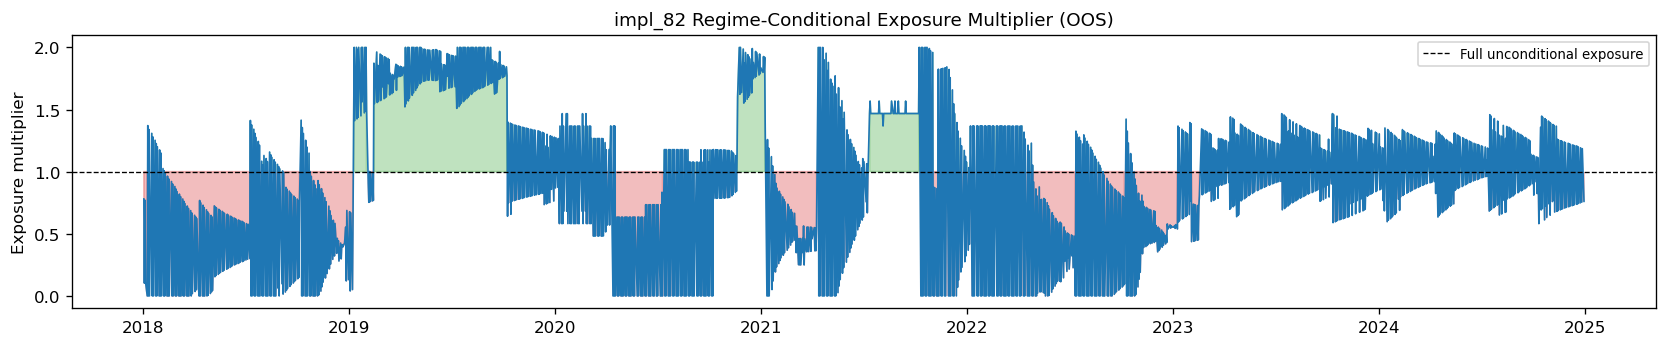

Mean multiplier: 0.914
Fraction of time at reduced exposure (<1.0): 54.7%


In [19]:
# Regime-conditional weights time series (illustrative)
# Uses impl_82 decomposition to weight exposure by expected IC
ic_by_state_82 = decomp_82.by_state['ic'].fillna(0).values
weights_82 = az.regime_weights(
    factor_82,
    oos_start=OOS_START,
    ic_by_state=ic_by_state_82,
)

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(weights_82.index, weights_82.values, color='#1f77b4', lw=1.0)
ax.axhline(1.0, color='k', lw=0.8, ls='--', label='Full unconditional exposure')
ax.fill_between(weights_82.index, 1.0, weights_82.values,
                where=weights_82.values >= 1.0, color='#2ca02c', alpha=0.3)
ax.fill_between(weights_82.index, 1.0, weights_82.values,
                where=weights_82.values < 1.0, color='#d62728', alpha=0.3)
ax.set_ylabel('Exposure multiplier', fontsize=10)
ax.set_title('impl_82 Regime-Conditional Exposure Multiplier (OOS)', fontsize=11)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'Mean multiplier: {weights_82.mean():.3f}')
print(f'Fraction of time at reduced exposure (<1.0): {(weights_82 < 1.0).mean():.1%}')

---
## Section D — Equity Curve: $10,000 Invested

**Purpose:** This section answers the most intuitive portfolio question: *if you had invested $10,000 in this factor strategy at the start of the OOS period (2018-01-01), how much would you have today — and how does regime conditioning change that trajectory?*

### Portfolio Construction

The portfolio is a **dollar-neutral long-short equity strategy** constructed using the rank-weight methodology from Phase 1:

1. At each date, stocks are ranked by their factor score.
2. Weights are computed as `w_i = (rank_i − 1)/(N−1) − 0.5`, then normalised to unit gross exposure.
3. The long book (positive weights) is exactly offset by the short book, so the portfolio has zero net market exposure.
4. The daily P&L is the dot product of the weight vector and the next-day return vector.

### Regime-Conditional vs. Unconditional

Two equity curves are shown:
- **Unconditional:** weights are applied at full exposure every day, regardless of regime.
- **Regime-conditional:** weights are scaled by the `regime_weights()` multiplier from Section C before being applied.  On days when the HSMM assigns the portfolio to a low-IC regime, exposure is reduced; on high-IC regime days, exposure is increased.

### How to Read the Chart

| Feature | Interpretation |
|---------|---------------|
| Final NAV > $10,000 | The factor has positive net return over the OOS period |
| Regime-conditional line above unconditional | Regime conditioning improved risk-adjusted returns |
| Drawdown depth | Maximum loss from peak — key risk metric |
| Slope stability | Whether the strategy's edge is consistent or episodic |

> **Important caveat:** This equity curve is *gross of transaction costs*.  A realistic net curve would subtract bid-ask spreads, market impact (Almgren et al. model), and borrow costs for the short book.  The Phase 3 cost model provides these estimates.  The gross curve shown here is an upper bound on realised performance.

/Users/franciscosimao/Documents/quant-learning/projects/qframe/notebooks/../src/qframe/factor_harness/walkforward.py:420: RuntimeWarning: Mean of empty slice
  row_mean = np.nanmean(w, axis=1, keepdims=True)
/var/folders/nr/wfbd07z166vg_d972x71kht80000gn/T/ipykernel_96758/2874563587.py:102: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from current font.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
/var/folders/nr/wfbd07z166vg_d972x71kht80000gn/T/ipykernel_96758/2874563587.py:102: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
/Users/franciscosimao/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/franciscosimao/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font

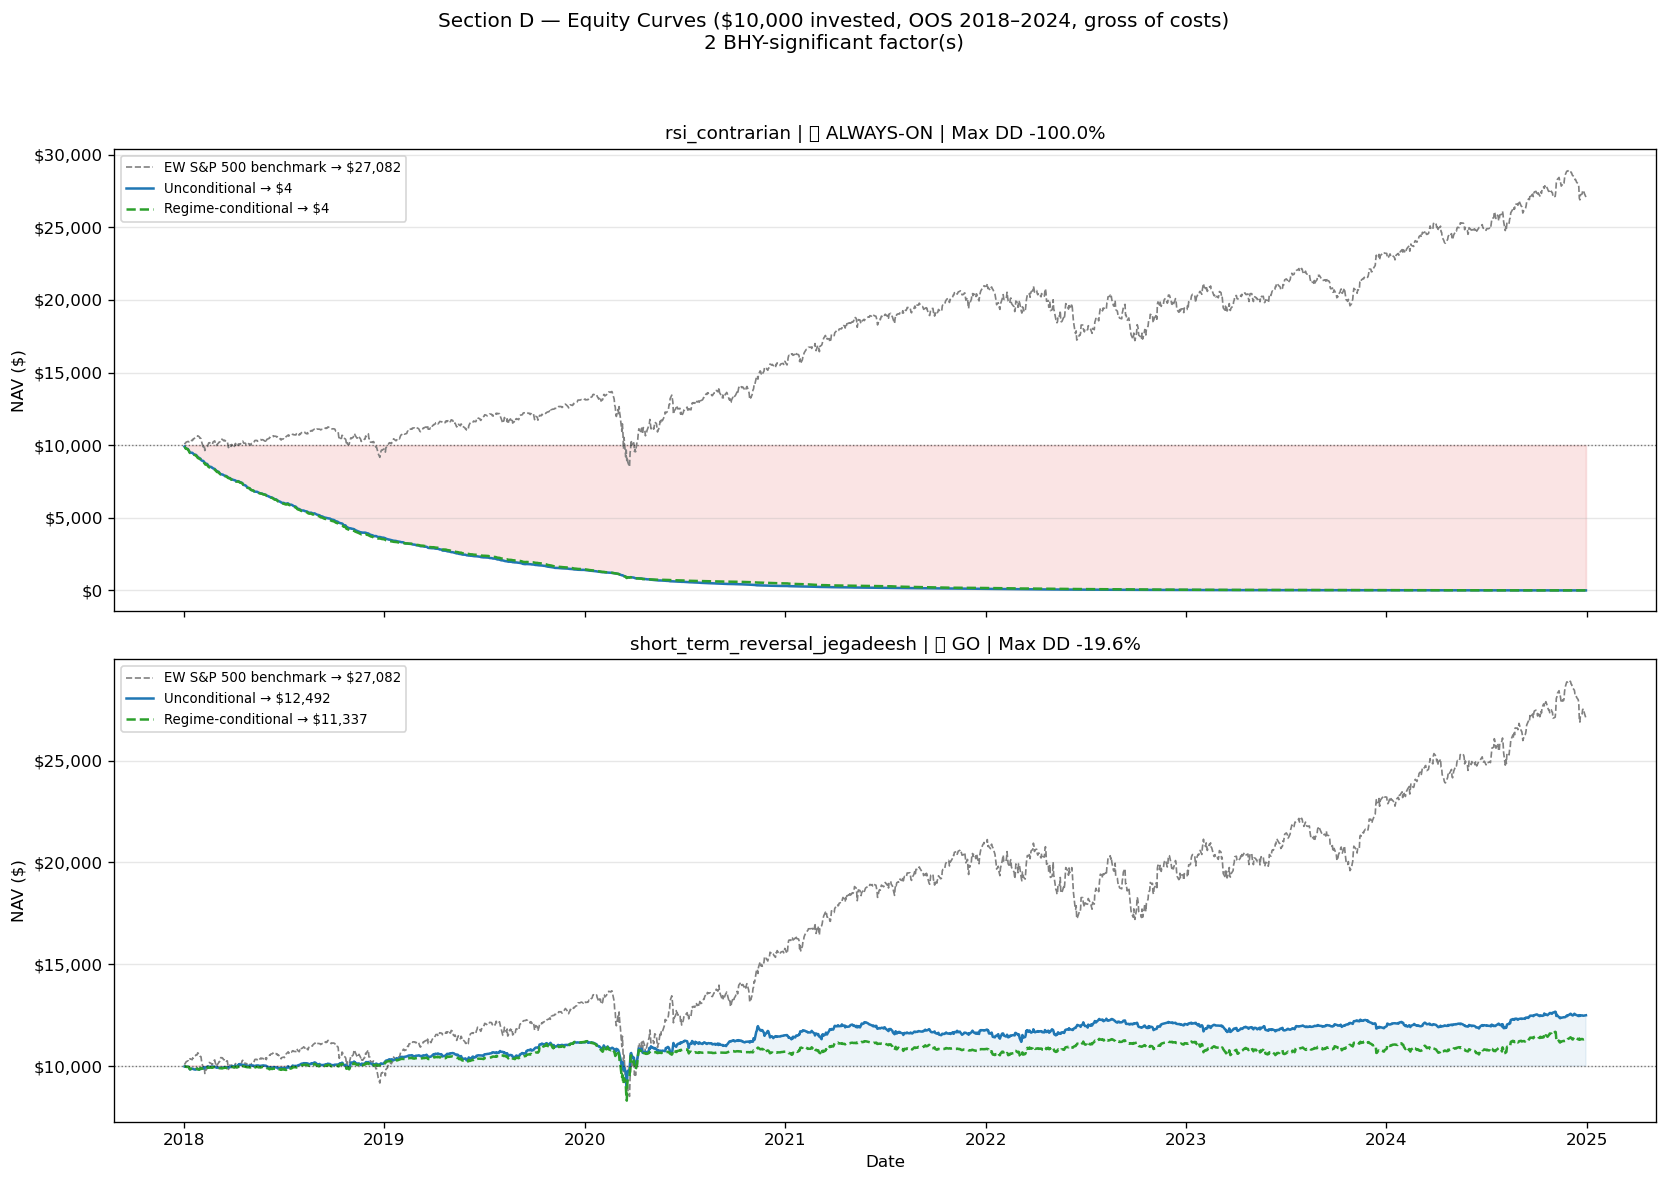


Final NAV Summary
rsi_contrarian
  Unconditional  : NAV=$        4  CAGR=-67.6%  MaxDD=-100.0%
  Regime-cond.   : NAV=$        4  CAGR=-67.2%  MaxDD=-100.0%
-----------------------------------------------------------------
short_term_reversal_jegadeesh
  Unconditional  : NAV=$   12,492  CAGR=+3.2%  MaxDD=-19.6%
  Regime-cond.   : NAV=$   11,337  CAGR=+1.8%  MaxDD=-26.0%
-----------------------------------------------------------------
Benchmark (EW S&P 500): NAV=$   27,082  CAGR=+15.3%


In [20]:
from qframe.factor_harness.walkforward import WalkForwardValidator

INITIAL_INVESTMENT = 10_000


def equity_curve(
    factor_df: pd.DataFrame,
    returns_df: pd.DataFrame,
    oos_start: str,
    regime_multiplier: object = None,
    initial: float = INITIAL_INVESTMENT,
) -> pd.Series:
    """Compute a gross equity curve starting at `initial` dollars."""
    weights = WalkForwardValidator._rank_weights(factor_df)
    weights = weights.loc[oos_start:]
    rets = returns_df.loc[oos_start:]
    shared = weights.columns.intersection(rets.columns)
    weights = weights[shared]
    rets = rets[shared]
    if regime_multiplier is not None:
        mult = regime_multiplier.reindex(weights.index).fillna(1.0)
        weights = weights.mul(mult, axis=0)
    daily_ret = (weights * rets).sum(axis=1)
    return initial * (1 + daily_ret.fillna(0)).cumprod()


# ── Benchmark: equal-weight S&P 500 ────────────────────────────────────────
bm = INITIAL_INVESTMENT * (1 + market_returns.loc[OOS_START:]).cumprod()

# ── Compute equity curves for all BHY-significant factors ──────────────────
# Use decomps dict (computed in Section B batch analysis above)
# If decomps is empty, fall back to decomp_82 / decomp_53 for the demo pair
if not decomps:
    # Fallback: build decomps from the existing demo analysis
    decomps = {}
    if 'decomp_82' in dir():
        decomps['trend_quality_calmar_ratio'] = decomp_82
    if 'decomp_53' in dir():
        decomps['impl_53_mean_reversion'] = decomp_53

factor_curves = {}  # factor_name → {'uncond': Series, 'cond': Series}

for name, factor_df in bhy_factor_dfs.items():
    if name not in decomps:
        continue
    decomp = decomps[name]
    ic_by_state = decomp.by_state['ic'].fillna(0).values
    mult = az.regime_weights(factor_df, oos_start=OOS_START, ic_by_state=ic_by_state)
    factor_curves[name] = {
        'uncond': equity_curve(factor_df, returns_df, OOS_START),
        'cond':   equity_curve(factor_df, returns_df, OOS_START, mult),
        'go':     decomp.lift >= LIFT_THRESHOLD,
    }

n_factors = len(factor_curves)
if n_factors == 0:
    print('No factor curves to plot (run batch analysis cells above first).')
else:
    # ── Plot: one row per BHY factor ────────────────────────────────────────
    fig, axes = plt.subplots(n_factors, 1, figsize=(14, 5 * n_factors),
                             sharex=True if n_factors > 1 else False,
                             squeeze=False)

    for i, (name, curves) in enumerate(factor_curves.items()):
        ax = axes[i][0]
        uncond = curves['uncond']
        cond   = curves['cond']
        b = bm.reindex(uncond.index)

        ax.plot(b.index,      b.values,      lw=1.0, color='grey',    ls='--',
                label=f'EW S&P 500 benchmark → ${b.iloc[-1]:,.0f}')
        ax.plot(uncond.index, uncond.values, lw=1.5, color='#1f77b4',
                label=f'Unconditional → ${uncond.iloc[-1]:,.0f}')
        ax.plot(cond.index,   cond.values,   lw=1.5, color='#2ca02c', ls='--',
                label=f'Regime-conditional → ${cond.iloc[-1]:,.0f}')
        ax.axhline(INITIAL_INVESTMENT, color='k', lw=0.8, ls=':', alpha=0.5)

        ax.fill_between(uncond.index, INITIAL_INVESTMENT, uncond.values,
                        where=uncond.values >= INITIAL_INVESTMENT,
                        interpolate=True, color='#1f77b4', alpha=0.08)
        ax.fill_between(uncond.index, INITIAL_INVESTMENT, uncond.values,
                        where=uncond.values < INITIAL_INVESTMENT,
                        interpolate=True, color='#d62728', alpha=0.12)

        peak = uncond.cummax()
        max_dd = ((uncond - peak) / peak).min()
        verdict = '🟢 GO' if curves['go'] else '🔵 ALWAYS-ON'
        ax.set_title(f'{name} | {verdict} | Max DD {max_dd:.1%}', fontsize=11)
        ax.set_ylabel('NAV ($)', fontsize=10)
        ax.legend(fontsize=8)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
        ax.grid(axis='y', alpha=0.3)

    if n_factors > 1:
        axes[-1][0].set_xlabel('Date', fontsize=10)

    fig.suptitle(
        f'Section D — Equity Curves ($10,000 invested, OOS 2018–2024, gross of costs)\n'
        f'{n_factors} BHY-significant factor(s)',
        fontsize=12,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ── Summary ─────────────────────────────────────────────────────────────────
print('\nFinal NAV Summary')
print('=' * 65)
for name, curves in factor_curves.items():
    uncond = curves['uncond']
    cond   = curves['cond']
    peak_u = uncond.cummax()
    peak_c = cond.cummax()
    dd_u = ((uncond - peak_u) / peak_u).min()
    dd_c = ((cond - peak_c) / peak_c).min()
    cagr_u = (uncond.iloc[-1] / INITIAL_INVESTMENT) ** (252 / len(uncond)) - 1
    cagr_c = (cond.iloc[-1] / INITIAL_INVESTMENT) ** (252 / len(cond)) - 1
    print(f'{name}')
    print(f'  Unconditional  : NAV=${uncond.iloc[-1]:>9,.0f}  CAGR={cagr_u:+.1%}  MaxDD={dd_u:.1%}')
    print(f'  Regime-cond.   : NAV=${cond.iloc[-1]:>9,.0f}  CAGR={cagr_c:+.1%}  MaxDD={dd_c:.1%}')
    print('-' * 65)
bm_sub = bm.reindex(list(factor_curves.values())[0]['uncond'].index)
bm_cagr = (bm_sub.iloc[-1] / INITIAL_INVESTMENT) ** (252 / len(bm_sub)) - 1
print(f'Benchmark (EW S&P 500): NAV=${bm_sub.iloc[-1]:>9,.0f}  CAGR={bm_cagr:+.1%}')
print('=' * 65)
